In [1]:
import os, sys, distutils.core
from IPython.display import clear_output

!python -m pip install pyyaml==5.1

!git clone 'https://github.com/facebookresearch/detectron2'

dist = distutils.core.run_setup("./detectron2/setup.py")

!python -m pip install {' '.join([f"'{x}'" for x in dist.install_requires])}

sys.path.insert(0, os.path.abspath('./detectron2'))

clear_output()

In [2]:
from detectron2.data.datasets import register_coco_instances
from detectron2.data import MetadataCatalog, DatasetCatalog


for dataset in ["train", "valid", "test"]:
    register_coco_instances(f"brain_tumor_{dataset}", {},
                            f"../input/brain-tumor-image-dataset-semantic-segmentation/{dataset}/_annotations.coco.json",
                            f"../input/brain-tumor-image-dataset-semantic-segmentation/{dataset}")

In [3]:
from detectron2.utils.visualizer import Visualizer

train_metadata = MetadataCatalog.get('brain_tumor_train')
train_dicts = DatasetCatalog.get('brain_tumor_train')

test_metadata = MetadataCatalog.get('brain_tumor_test')
test_dicts =  DatasetCatalog.get('brain_tumor_test')

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer

def plot_images(dataset_dict, dataset_metadata, image_scale):
    images = np.random.permutation(dataset_dict)[:2]
    
    fig, axis = plt.subplots(1, 2, figsize = (7, 5), dpi = 100)
    
    for i in range(2):
        im = images[i]
        img_link = im['file_name']
        img_id = im['image_id']
        img = cv2.imread(img_link)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        visualizer = Visualizer(img, metadata=dataset_metadata, scale=image_scale)
        vis = visualizer.draw_dataset_dict(im)
        final_img = vis.get_image()
        
        axis[i].set_title('image id: ' + str(img_id), fontsize = 10)
        axis[i].axis('off')
        axis[i].imshow(final_img)

    fig.tight_layout()

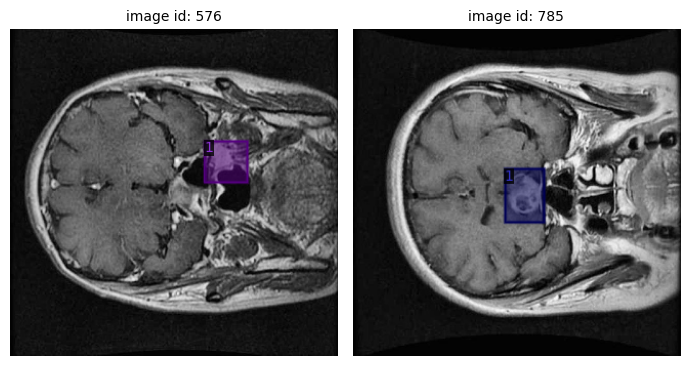

In [5]:
plot_images(train_dicts, train_metadata, image_scale = 0.5)

In [6]:
from detectron2.config import get_cfg
from detectron2 import model_zoo

num_epoch = 3300
lr = 1e-4

cfg = get_cfg()

cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_X_101_32x8d_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ('brain_tumor_train')
cfg.DATASETS.TEST = ()
cfg.DATALOADER.NUM_WORKERS = 4
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_X_101_32x8d_FPN_3x.yaml")
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = lr
cfg.SOLVER.MAX_ITER = num_epoch  
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 512  
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 3

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

In [7]:
from detectron2.engine import DefaultTrainer

trainer = DefaultTrainer(cfg) 
trainer.resume_or_load(resume=False)
trainer.train()

model_final_2d9806.pkl: 431MB [00:01, 218MB/s]                               
/usr/local/lib/python3.10/dist-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [8]:
import pickle
from detectron2.engine import DefaultPredictor

cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")  
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.6

predictor = DefaultPredictor(cfg)

with open("cfg.pkl", "wb") as file:
    pickle.dump(cfg, file)

/usr/local/lib/python3.10/dist-packages/fvcore/common/checkpoint.py:252: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_location=torch.device("cpu"))

In [9]:
import json

def reading_metrics(path):
    metrics = []
    
    with open(path, 'r') as file:
        for line in file:
            metrics.append(json.loads(line))
            
    return metrics

In [10]:
def get_metric(metrics, specific_metric):
    metric = []
    
    for i in range(len(metrics)):
        try: 
            metric.append(metrics[i][specific_metric])
        except KeyError:
            pass
            
    return metric

In [11]:
train_metrics = reading_metrics('/kaggle/working/output/metrics.json')

iters = get_metric(train_metrics, 'iteration')
total_loss = get_metric(train_metrics, 'total_loss')
cls_acc = get_metric(train_metrics, 'fast_rcnn/cls_accuracy')
loss_mask = get_metric(train_metrics, 'loss_mask')
loss_box_reg = get_metric(train_metrics, 'loss_box_reg')

if len(iters) == len(total_loss) == len(cls_acc) == len(loss_mask) == len(loss_box_reg):
    pass
else:
    iters = iters[:-1]

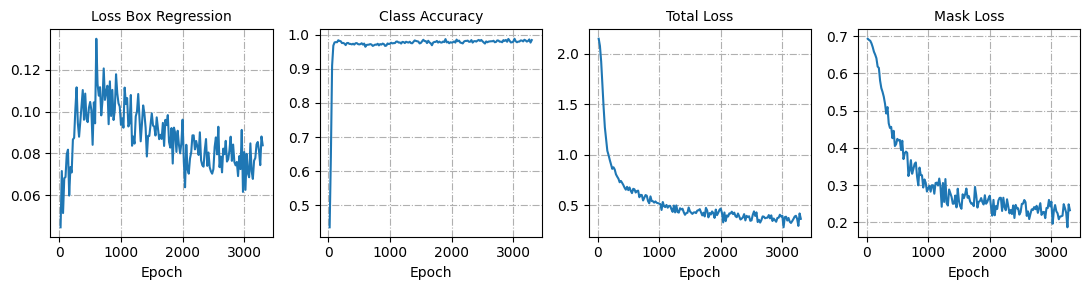

In [30]:
fig, axis = plt.subplots(1, 4, figsize = (11, 3), dpi = 100)

axis[0].grid(linestyle = 'dashdot')
axis[0].plot(iters, loss_box_reg)
axis[0].set_xlabel('Epoch', fontsize = 10)
axis[0].set_title('Loss Box Regression', fontsize = 10, color = 'black')

axis[1].grid(linestyle = 'dashdot')
axis[1].plot(iters, cls_acc)
axis[1].set_xlabel('Epoch', fontsize = 10)
axis[1].set_title('Class Accuracy', fontsize = 10, color = 'black')

axis[2].grid(linestyle = 'dashdot')
axis[2].plot(iters, total_loss)
axis[2].set_xlabel('Epoch', fontsize = 10)
axis[2].set_title('Total Loss', fontsize = 10, color = 'black')

axis[3].grid(linestyle = 'dashdot')
axis[3].plot(iters, loss_mask)
axis[3].set_xlabel('Epoch', fontsize = 10)
axis[3].set_title('Mask Loss', fontsize = 10, color = 'black')

fig.tight_layout()

In [13]:
from detectron2.utils.visualizer import ColorMode

def plot_pred(dataset_dict, dataset_metadata, image_scale):
    images = np.random.permutation(dataset_dict)[:3]
    
    fig, axis = plt.subplots(3, 2, figsize = (8, 6), dpi = 120)
    
    for i in range(3):
        im = images[i]
        img_link = im['file_name']
        img_id = im['image_id']
        img = cv2.imread(img_link)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        visualizer1 = Visualizer(img, metadata=dataset_metadata, scale=image_scale)
        vis_original = visualizer1.draw_dataset_dict(im)
        original_bbox = vis_original.get_image()
        
        visualizer2 = Visualizer(img[:, :, ::-1], metadata=dataset_metadata, scale=image_scale, instance_mode=ColorMode.IMAGE_BW)
        outputs = predictor(img)
        out = visualizer2.draw_instance_predictions(outputs["instances"].to("cpu"))
        out_img = cv2.cvtColor(out.get_image(), cv2.COLOR_BGR2RGB)
        final_bbox = cv2.cvtColor(out_img, cv2.COLOR_BGR2RGB)
        
        axis[i][0].set_title('actual bounding box (id: ' + str(img_id) +')', fontsize = 10)
        axis[i][0].axis('off')
        axis[i][0].imshow(original_bbox)
        
        axis[i][1].set_title('predicted bounding box (id: ' + str(img_id) +')', fontsize = 10, color = 'red')
        axis[i][1].axis('off')
        axis[i][1].imshow(final_bbox[:, :, ::-1])
        
    fig.tight_layout()

In [14]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader

evaluator = COCOEvaluator('brain_tumor_test', False, output_dir='./output/')

test_loader = build_detection_test_loader(cfg, 'brain_tumor_test')

inference_on_dataset(trainer.model, test_loader, evaluator)

Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.09s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.374
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.719
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.324
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.319
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.426
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.452
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.503
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.503
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

OrderedDict([('bbox',
              {'AP': 37.38325682640662,
               'AP50': 71.87784387520495,
               'AP75': 32.38235989956283,
               'APs': 0.0,
               'APm': 31.874112445693072,
               'APl': 42.55834579169084,
               'AP-Tumor': nan,
               'AP-0': 24.27590003625214,
               'AP-1': 50.490613616561106}),
             ('segm',
              {'AP': 35.13095141235138,
               'AP50': 70.23715444372553,
               'AP75': 33.29036511696341,
               'APs': 0.0,
               'APm': 30.014163736187268,
               'APl': 39.249647983549536,
               'AP-Tumor': nan,
               'AP-0': 21.9723163751402,
               'AP-1': 48.289586449562556})])

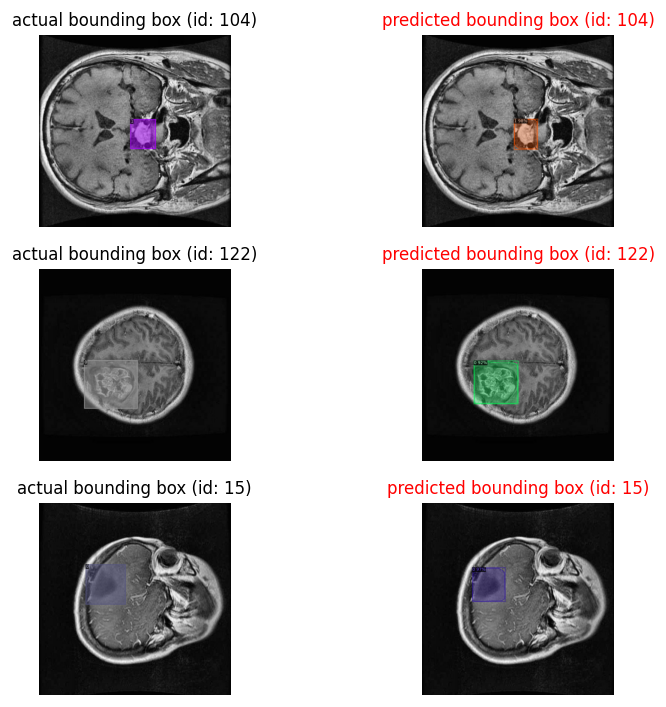

In [41]:
plot_pred(test_dicts, test_metadata, image_scale=1.0)